# HW 1 Report

Linda Jin, Shobhit Gupta


# Part 0

In [9]:
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [10]:
ROOT = Path.cwd()
PART0_DIR = ROOT / "out" / "submission" / "part0"
PLOTS_DIR = PART0_DIR / "plots"
TABLES_DIR = PART0_DIR / "tables"

SANITY_FULL = PART0_DIR / "sanity_full"
SANITY_MASK3 = PART0_DIR / "sanity_mask3"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("part0:", PART0_DIR)


root: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1
part0: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part0


In [11]:
def run(cmd: str):
    print(f"\n$ {cmd}")
    result = subprocess.run(cmd, shell=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with code {result.returncode}: {cmd}")


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


## Train Sanity Models

In [12]:
run(
    "python train.py --mode sanity --steps 1200 --mask_prefix_tokens 0 "
    "--batch_size 1 --lr 1e-2 --eval_interval 50 --log_interval 100 "
    "--out_dir out/submission/part0/sanity_full --n_layer 1 --n_head 2 --n_embd 32 --bias"
)

run(
    "python train.py --mode sanity --steps 1200 --mask_prefix_tokens 3 "
    "--batch_size 1 --lr 1e-2 --eval_interval 50 --log_interval 100 "
    "--out_dir out/submission/part0/sanity_mask3 --n_layer 1 --n_head 2 --n_embd 32 --bias"
)



$ python train.py --mode sanity --steps 1200 --mask_prefix_tokens 0 --batch_size 1 --lr 1e-2 --eval_interval 50 --log_interval 100 --out_dir out/submission/part0/sanity_full --n_layer 1 --n_head 2 --n_embd 32 --bias
number of parameters: 0.01M
device=mps train=1 val=1 test=1 batch_size=1
step=1 train_loss=1.630736 train_acc=nan val_loss=1.630736 val_acc=nan test_loss=1.630736 test_acc=nan
step=100 train_loss=0.000360 train_acc=nan val_loss=0.000360 val_acc=nan test_loss=0.000360 test_acc=nan
step=200 train_loss=0.000039 train_acc=nan val_loss=0.000039 val_acc=nan test_loss=0.000039 test_acc=nan
step=300 train_loss=0.000002 train_acc=nan val_loss=0.000002 val_acc=nan test_loss=0.000002 test_acc=nan
step=400 train_loss=0.000000 train_acc=nan val_loss=0.000000 val_acc=nan test_loss=0.000000 test_acc=nan
step=500 train_loss=0.000000 train_acc=nan val_loss=0.000000 val_acc=nan test_loss=0.000000 test_acc=nan
step=600 train_loss=0.000000 train_acc=nan val_loss=0.000000 val_acc=nan test_loss

## Inference and Contract Verification

In [ ]:
# Memorization generation
run("python inference.py --checkpoint_dir out/submission/part0/sanity_full --task sanity")

# Suffix generation from a fixed prefix
run(
    "python inference.py --checkpoint_dir out/submission/part0/sanity_mask3 "
    "--task custom --prompt_tokens '<BOS>,I,love,machine' --max_new_tokens 2"
)

# Contract check
run(
    "python - <<'PY'\n"
    "from part_0_1_contract import load_model_and_tokenizer, get_bos_token\n"
    "m, tok = load_model_and_tokenizer('out/submission/part0/sanity_full')\n"
    "print('BOS:', get_bos_token(tok))\n"
    "PY"
)



$ python inference.py --checkpoint_dir out/submission/part0/sanity_full --task sanity
device=mps
number of parameters: 0.01M
generated_ids: [1, 3, 4, 5, 6, 2]
generated_tokens: ['<BOS>', 'I', 'love', 'machine', 'learning', '<EOS>']

$ python inference.py --checkpoint_dir out/submission/part0/sanity_mask3 --task custom --prompt_tokens '<BOS>,I,love,machine' --max_new_tokens 2
device=mps
number of parameters: 0.01M
prompt_tokens: ['<BOS>', 'I', 'love', 'machine']
generated_ids: [1, 3, 4, 5, 6, 2]
generated_tokens: ['<BOS>', 'I', 'love', 'machine', 'learning', '<EOS>']

$ python - <<'PY'
from part_0_1_contract import load_model_and_tokenizer, get_bos_token
m, tok = load_model_and_tokenizer('out/submission/part0/sanity_full')
print('BOS:', get_bos_token(tok))
PY
number of parameters: 0.01M
BOS: <BOS>


## Summarize Metrics

In [14]:
m_full = load_json(SANITY_FULL / "metrics.json")
m_mask = load_json(SANITY_MASK3 / "metrics.json")

summary_df = pd.DataFrame([
    {
        "run": "sanity_full",
        "mask_prefix_tokens": 0,
        "best_step": m_full.get("step"),
        "train_loss": m_full.get("train_loss"),
        "val_loss": m_full.get("val_loss"),
        "test_loss": m_full.get("test_loss"),
    },
    {
        "run": "sanity_mask3",
        "mask_prefix_tokens": 3,
        "best_step": m_mask.get("step"),
        "train_loss": m_mask.get("train_loss"),
        "val_loss": m_mask.get("val_loss"),
        "test_loss": m_mask.get("test_loss"),
    },
])

summary_df.to_csv(TABLES_DIR / "part0_summary.csv", index=False)
summary_df


,run,mask_prefix_tokens,best_step,train_loss,val_loss,test_loss
0,sanity_full,0,450,0.0,0.0,0.0
1,sanity_mask3,3,400,0.0,0.0,0.0


## Plot Training Curves

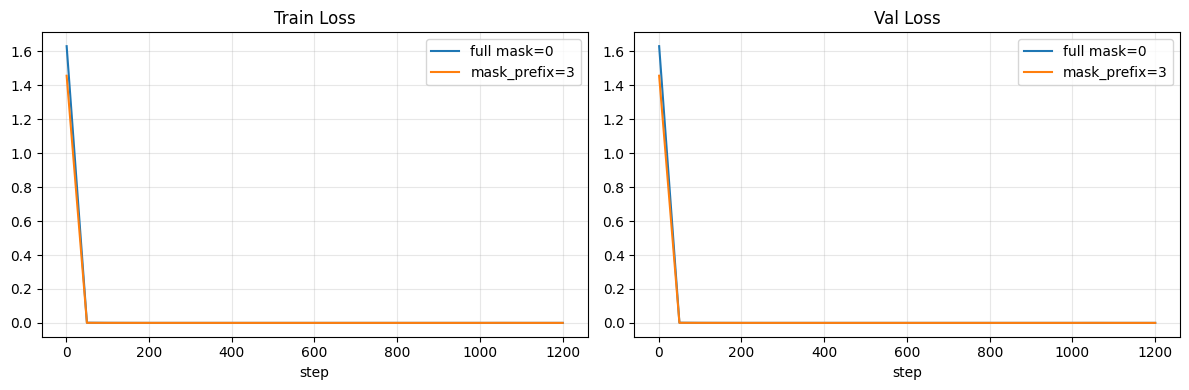

In [15]:
h_full = pd.read_csv(SANITY_FULL / "history.csv")
h_mask = pd.read_csv(SANITY_MASK3 / "history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(h_full["step"], h_full["train_loss"], label="full mask=0")
axes[0].plot(h_mask["step"], h_mask["train_loss"], label="mask_prefix=3")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("step")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(h_full["step"], h_full["val_loss"], label="full mask=0")
axes[1].plot(h_mask["step"], h_mask["val_loss"], label="mask_prefix=3")
axes[1].set_title("Val Loss")
axes[1].set_xlabel("step")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / "part0_loss_curves.png", dpi=180)
plt.show()
